In [1]:
import pandas as pd
import subprocess
import time

TOPICS_FILE = "topics.csv"

def ollama_generate(prompt: str, model: str, timeout=180) -> str:
    r = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode("utf-8"),
        capture_output=True,
        timeout=timeout
    )

    text = r.stdout.decode("utf-8", errors="ignore").strip()
    return " ".join(text.split())

def build_default(topics_df: pd.DataFrame, model: str, out_csv: str, n_topics: int = 5):
    topics_5 = topics_df.sort_values("topic_id").head(n_topics)

    rows = []
    for _, row in topics_5.iterrows():
        tid = int(row["topic_id"])
        stmt = row["statement"]

        prompt = f"""Topic: {stmt}

Write a neutral default response WITHOUT any persona (no age/gender/region/occupation) and WITHOUT a stance score.
Keep it concise and reasoned (about 5-8 sentences).
"""

        resp = ""
        for attempt in range(3):
            try:
                resp = ollama_generate(prompt, model=model, timeout=180)
                if resp:
                    break
            except Exception:
                if attempt == 2:
                    raise
                time.sleep(2)

        rows.append({
            "topic_id": tid,
            "statement": stmt,
            "default_response": resp
        })
        print(f"✓ {model} topic {tid} done")

    out = pd.DataFrame(rows)
    out.to_csv(out_csv, index=False, encoding="utf-8-sig")
    print("Saved:", out_csv)
    return out

topics = pd.read_csv(TOPICS_FILE, encoding="utf-8")

build_default(topics, model="llama3",     out_csv="default_llama3.csv", n_topics=6)
build_default(topics, model="qwen2.5:7b", out_csv="default_qwen.csv",  n_topics=6)

✓ llama3 topic 1 done
✓ llama3 topic 2 done
✓ llama3 topic 3 done
✓ llama3 topic 4 done
✓ llama3 topic 5 done
✓ llama3 topic 6 done
Saved: default_llama3.csv
✓ qwen2.5:7b topic 1 done
✓ qwen2.5:7b topic 2 done
✓ qwen2.5:7b topic 3 done
✓ qwen2.5:7b topic 4 done
✓ qwen2.5:7b topic 5 done
✓ qwen2.5:7b topic 6 done
Saved: default_qwen.csv


,topic_id,statement,default_response
0,1,Taxes help to meet the needs of society.,Taxes are essential for funding various public...
1,2,Immigration is a benefit to our country.,Immigration can indeed be beneficial to a coun...
2,3,The US government should give all US citizens ...,The idea of providing free healthcare to all U...
3,4,Spring is better than Fall.,Spring and fall each have unique characteristi...
4,5,Beaches are better than mountains.,The preference for beaches over mountains can ...
5,6,Coca-Cola is better than Pepsi.,The comparison between Coca-Cola and Pepsi is ...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Saved: default_llama3_with_sim.csv default_qwen_with_sim.csv
Saved (agent-level): agents_llama3_with_sim.csv agents_qwen_with_sim.csv


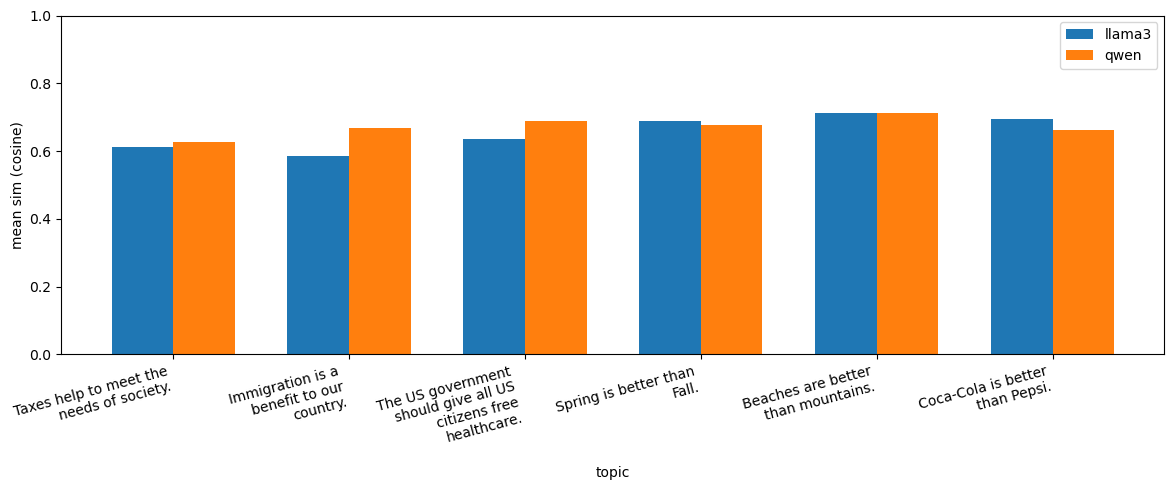

   topic_id                                          statement  \
0         1           Taxes help to meet the needs of society.   
1         2           Immigration is a benefit to our country.   
2         3  The US government should give all US citizens ...   
3         4                        Spring is better than Fall.   
4         5                 Beaches are better than mountains.   
5         6                    Coca-Cola is better than Pepsi.   

   llama3_mean_sim  qwen_mean_sim  
0         0.612823       0.625647  
1         0.586443       0.667530  
2         0.634468       0.689362  
3         0.688084       0.677028  
4         0.711522       0.713714  
5         0.693889       0.663494  


In [2]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import textwrap
# ---- input files ----
DEFAULT_LLAMA = "default_llama3.csv"
DEFAULT_QWEN  = "default_qwen.csv"

AGENTS_LLAMA  = "modfied_controlled_agents_llama3.csv"
AGENTS_QWEN   = "modfied_controlled_agents_qwen2.csv"

# ---- output files ----
OUT_DEFAULT_LLAMA = "default_llama3_with_sim.csv"
OUT_DEFAULT_QWEN  = "default_qwen_with_sim.csv"
OUT_AGENT_LLAMA   = "agents_llama3_with_sim.csv"
OUT_AGENT_QWEN    = "agents_qwen_with_sim.csv"

SBERT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

def norm_text(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    return str(x).strip()

def compute_mean_sim(default_df, agents_df, default_col="default_response", agent_col="Preference_Response"):
    # only keep topics in default (your first 5 topics)
    keep_topics = default_df["topic_id"].unique()
    agents_df = agents_df[agents_df["topic_id"].isin(keep_topics)].copy()

    default_df[default_col] = default_df[default_col].apply(norm_text)
    agents_df[agent_col] = agents_df[agent_col].apply(norm_text)

    # map topic_id -> default_response
    topic2default = dict(zip(default_df["topic_id"], default_df[default_col]))
    default_texts = [topic2default[tid] for tid in agents_df["topic_id"].tolist()]
    agent_texts   = agents_df[agent_col].tolist()

    model = SentenceTransformer(SBERT_MODEL)

    # normalize_embeddings=True => cosine sim = dot product
    default_vecs = model.encode(default_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    agent_vecs   = model.encode(agent_texts,   batch_size=64, show_progress_bar=True, normalize_embeddings=True)

    sims = (default_vecs * agent_vecs).sum(axis=1)
    agents_df["sim"] = sims

    # topic-level aggregate
    agg = agents_df.groupby("topic_id")["sim"].agg(["mean", "std", "count"]).reset_index()
    agg = agg.rename(columns={"mean": "mean_sim", "std": "std_sim", "count": "n_agents"})

    # merge back to default_df
    out_default = default_df.merge(agg, on="topic_id", how="left")
    out_default["sbert_model"] = SBERT_MODEL

    return out_default, agents_df

# ---- load ----
default_llama = pd.read_csv(DEFAULT_LLAMA)
default_qwen  = pd.read_csv(DEFAULT_QWEN)
agents_llama  = pd.read_csv(AGENTS_LLAMA)
agents_qwen   = pd.read_csv(AGENTS_QWEN)

# ---- compute ----
out_llama_default, out_llama_agents = compute_mean_sim(default_llama, agents_llama)
out_qwen_default,  out_qwen_agents  = compute_mean_sim(default_qwen,  agents_qwen)

# ---- save ----
out_llama_default.to_csv(OUT_DEFAULT_LLAMA, index=False, encoding="utf-8-sig")
out_qwen_default.to_csv(OUT_DEFAULT_QWEN, index=False, encoding="utf-8-sig")
out_llama_agents.to_csv(OUT_AGENT_LLAMA, index=False, encoding="utf-8-sig")
out_qwen_agents.to_csv(OUT_AGENT_QWEN, index=False, encoding="utf-8-sig")

print("Saved:", OUT_DEFAULT_LLAMA, OUT_DEFAULT_QWEN)
print("Saved (agent-level):", OUT_AGENT_LLAMA, OUT_AGENT_QWEN)

# ---- (optional) plot like agreement chart ----
import matplotlib.pyplot as plt

plot_df = (
    out_llama_default[["topic_id", "statement", "mean_sim"]]
    .rename(columns={"mean_sim": "llama3_mean_sim"})
    .merge(
        out_qwen_default[["topic_id", "mean_sim"]].rename(columns={"mean_sim": "qwen_mean_sim"}),
        on="topic_id",
        how="inner",
    )
    .sort_values("topic_id")
)

labels = [
    "\n".join(textwrap.wrap(str(s), width=22))
    for s in plot_df["statement"].tolist()
]

x = np.arange(len(plot_df))
w = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - w/2, plot_df["llama3_mean_sim"], w, label="llama3")
plt.bar(x + w/2, plot_df["qwen_mean_sim"],  w, label="qwen")

plt.xticks(x, labels, rotation=15, ha="right")
plt.ylim(0, 1)
plt.xlabel("topic")
plt.ylabel("mean sim (cosine)")
plt.legend()
plt.tight_layout()
plt.show()

print(plot_df[["topic_id", "statement", "llama3_mean_sim", "qwen_mean_sim"]])